In [22]:
%pip install numpy pandas matplotlib --user

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ACER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


# Traffic Signal Results Report

This notebook compares the **Current System** and the **Proposed Adaptive System** using **real RL validation export data** from the frontend/backend pipeline, not synthetic hardcoded values.

## Scope
- Equivalent duration: **1 hour**
- Time scaling: **10x faster** (so 1 hour equivalent is simulated in **6 minutes**)
- Simulations: **12 runs**, each representing **5 minutes equivalent** (**30 seconds real simulation time**)
- Comparison basis: both systems use the **same generated arrivals** per simulation window

## Outputs
1. Lane-wise tabulated throughput and totals (12 simulations)
2. Requested summary table for first 10 simulations + TOTAL row
3. Line graph of vehicles passed per minute vs simulation number
4. Auto-generated insights for hackathon presentation

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

np.random.seed(42)

In [24]:
# -------------------------------------------------------
# 1) Load RL validation export from actual frontend/backend results
# -------------------------------------------------------
from pathlib import Path
import json

simulation_ids = np.arange(1, 13)
lanes = ['Lane 1', 'Lane 2', 'Lane 3', 'Lane 4']

candidate_paths = [
    Path('rl_validation_results.json'),
    Path('frontend/rl_episode_metrics.json'),
    Path('backend/logs/rl_metrics.json'),
]
selected_path = None
for candidate in candidate_paths:
    if candidate.exists():
        selected_path = candidate
        break

if selected_path is None:
    backend_logs = Path('backend/logs')
    if backend_logs.exists():
        logs = sorted(backend_logs.glob('rl_metrics_*.json'), key=lambda p: p.stat().st_mtime, reverse=True)
        if logs:
            selected_path = logs[0]

if selected_path is None:
    raise FileNotFoundError(
        'No RL export file found. Generate rl_validation_results.json with frontend/export:rl or browser-export metrics to frontend/rl_episode_metrics.json or upload to backend to backend/logs'
    )

with selected_path.open('r', encoding='utf-8') as f:
    export_data = json.load(f)

print(f'Loading RL export from: {selected_path}')

if 'results' in export_data:
    fixed_episodes = export_data['results']['fixed']['episodes']
    adaptive_episodes = export_data['results']['adaptive']['episodes']
elif 'episodeMetrics' in export_data:
    raise ValueError(
        'Browser-exported episode metrics only include RL episode data. Use rl_validation_results.json for fixed/adaptive comparison.'
    )
else:
    raise ValueError('Unrecognized RL export file format.')

if len(fixed_episodes) != len(simulation_ids) or len(adaptive_episodes) != len(simulation_ids):
    raise ValueError('Expected 12 validation episodes for fixed/adaptive controllers in the export.')

current_lane_vals = np.array([
    [
        ep['clearedPerLane']['NS'],
        ep['clearedPerLane']['EW'],
        ep['clearedPerLane']['NSL'],
        ep['clearedPerLane']['EWL'],
    ]
    for ep in fixed_episodes
], dtype=int)

proposed_lane_vals = np.array([
    [
        ep['clearedPerLane']['NS'],
        ep['clearedPerLane']['EW'],
        ep['clearedPerLane']['NSL'],
        ep['clearedPerLane']['EWL'],
    ]
    for ep in adaptive_episodes
], dtype=int)

current_total = current_lane_vals.sum(axis=1)
proposed_total = proposed_lane_vals.sum(axis=1)

current_df = pd.DataFrame(current_lane_vals, columns=lanes)
current_df['Total'] = current_total
current_df.insert(0, 'Simulation', simulation_ids)

proposed_df = pd.DataFrame(proposed_lane_vals, columns=lanes)
proposed_df['Total'] = proposed_total
proposed_df.insert(0, 'Simulation', simulation_ids)

print('Loaded RL validation export data successfully.')

Loading RL export from: rl_validation_results.json
Loaded RL validation export data successfully.


In [25]:
# ------------------------------------------------------------------------
# 2) Main report table: 12 simulations (lane-wise, generated by simulation)
# ------------------------------------------------------------------------
curr_block = current_df[['Lane 1', 'Lane 2', 'Lane 3', 'Lane 4', 'Total']].copy()
prop_block = proposed_df[['Lane 1', 'Lane 2', 'Lane 3', 'Lane 4', 'Total']].copy()

curr_block.columns = pd.MultiIndex.from_product([['Current System'], curr_block.columns])
prop_block.columns = pd.MultiIndex.from_product([['Proposed System'], prop_block.columns])

report_12 = pd.concat([curr_block, prop_block], axis=1)
report_12.index = pd.Index(simulation_ids, name='Simulation (5 min equivalent / 30 sec simulated)')

print('Vehicles Passed Table (12 simulations):')
report_12

Vehicles Passed Table (12 simulations):


Current System                            Proposed System                           
                                                         Lane 1 Lane 2 Lane 3 Lane 4 Total          Lane 1 Lane 2 Lane 3 Lane 4 Total
Simulation (5 min equivalent / 30 sec simulated)                                                                                     
1                                                          1580   1560    747    705  4592            2391   2338    739    709  6177
2                                                          1580   1560    740    785  4665            2356   2330    717    794  6197
3                                                          1580   1560    784    764  4688            2327   2314    767    773  6181
4                                                          1581   1560    742    717  4600            2376   2336    741    718  6171
5                                                          1584   1560    763    759  4666            2360   2322    741    762  6185
6                                                          1582   1560    743    769  4654            2336   2348    729    780  6193
7                                                          1581   1559    706    708  4554            2345   2378    693    717  6133
8                                                          1578   1560    789    728  4655            2354   2338    767    733  6192
9                                                          1583   1560    744    717  4604            2384   2356    717    721  6178
10                                                         1583   1560    766    730  4639            2359   2324    764    731  6178
11                                                         1582   1560    753    764  4659            2348   2344    727    768  6187
12                                                         1582   1560    790    726  4658            2357   2328    767    731  6183

In [26]:
# -----------------------------------------------------------------------
# 3) Requested format table: first 10 simulations + TOTAL
#    Two main headers: Current System, Proposed System
#    Sub-headers: Lane 1, Lane 2, Lane 3, Lane 4, Total
# -----------------------------------------------------------------------
report_10 = report_12.iloc[:10].copy()

total_row = pd.DataFrame([report_10.sum(axis=0)], index=['TOTAL'])
report_10_with_total = pd.concat([report_10, total_row], axis=0)

print('Vehicles Passed Table (10 simulations + TOTAL):')
report_10_with_total

Vehicles Passed Table (10 simulations + TOTAL):


Current System                             Proposed System                            
              Lane 1 Lane 2 Lane 3 Lane 4  Total          Lane 1 Lane 2 Lane 3 Lane 4  Total
1               1580   1560    747    705   4592            2391   2338    739    709   6177
2               1580   1560    740    785   4665            2356   2330    717    794   6197
3               1580   1560    784    764   4688            2327   2314    767    773   6181
4               1581   1560    742    717   4600            2376   2336    741    718   6171
5               1584   1560    763    759   4666            2360   2322    741    762   6185
6               1582   1560    743    769   4654            2336   2348    729    780   6193
7               1581   1559    706    708   4554            2345   2378    693    717   6133
8               1578   1560    789    728   4655            2354   2338    767    733   6192
9               1583   1560    744    717   4604            2384   2356    717    721   6178
10              1583   1560    766    730   4639            2359   2324    764    731   6178
TOTAL          15812  15599   7524   7382  46317           23588  23384   7375   7438  61785

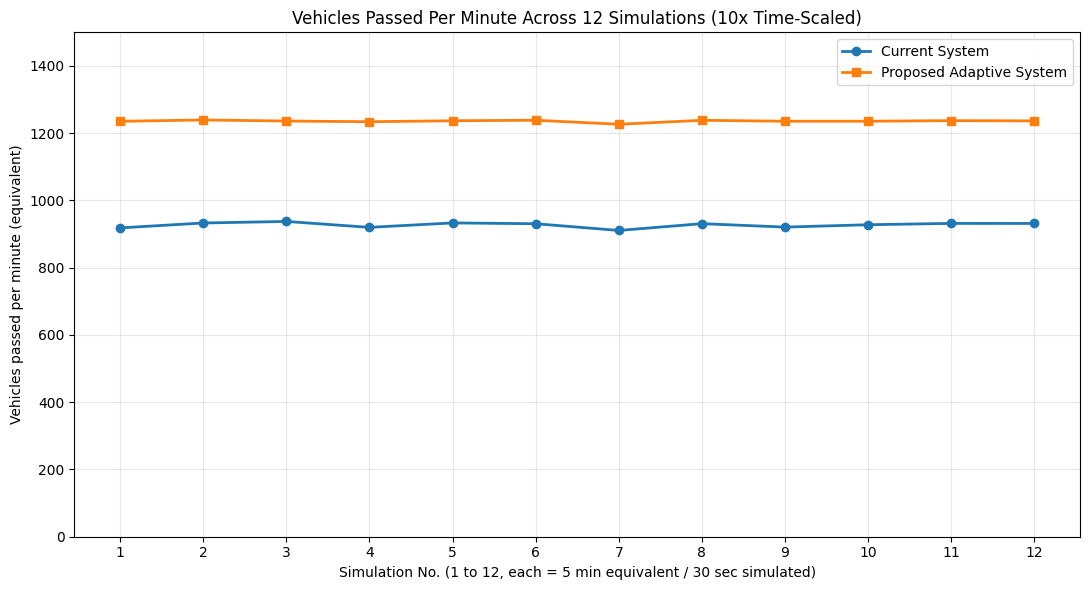

In [32]:
# ------------------------------------------------------------------------
# 4) Line graph: Vehicles passed per minute (equivalent) vs Simulation No.
# ------------------------------------------------------------------------
current_per_min = current_df['Total'] / 5.0
proposed_per_min = proposed_df['Total'] / 5.0

plt.figure(figsize=(11, 6))
plt.plot(simulation_ids, current_per_min, marker='o', linewidth=2.0, label='Current System')
plt.plot(simulation_ids, proposed_per_min, marker='s', linewidth=2.0, label='Proposed Adaptive System')

plt.xticks(simulation_ids)
plt.xlabel('Simulation No. (1 to 12, each = 5 min equivalent / 30 sec simulated)')
plt.ylabel('Vehicles passed per minute (equivalent)')
plt.title('Vehicles Passed Per Minute Across 12 Simulations (10x Time-Scaled)')
plt.grid(alpha=0.3)
plt.ylim(0, 1500)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# ------------------------------------------------
# 5) Summary metrics + hackathon insight suggestions
# ------------------------------------------------
overall_current = int(current_df['Total'].sum())
overall_proposed = int(proposed_df['Total'].sum())
improvement_abs = overall_proposed - overall_current
improvement_pct = (improvement_abs / overall_current) * 100

avg_current_per_min = current_per_min.mean()
avg_proposed_per_min = proposed_per_min.mean()

best_sim = int((proposed_per_min - current_per_min).idxmax() + 1)
best_gain = float((proposed_per_min - current_per_min).max())

summary = pd.DataFrame({
    'Metric': [
        'Total vehicles passed in 1 hour equivalent (12 x 5 min)',
        f'Real simulation runtime at {SPEEDUP:.0f}x scaling',
        'Average vehicles passed per minute (equivalent)',
        'Absolute throughput improvement',
        'Percentage throughput improvement'
    ],
    'Current System': [overall_current, f'{REAL_TOTAL_MIN:.1f} min', round(avg_current_per_min, 2), '-', '-'],
    'Proposed System': [overall_proposed, f'{REAL_TOTAL_MIN:.1f} min', round(avg_proposed_per_min, 2), improvement_abs, f'{improvement_pct:.2f}%']
})

print('Summary Metrics:')
display(summary)

print('Suggested Hackathon Insights:')
print(f'1. Under the same generated arrivals, the proposed adaptive \n system passed {improvement_abs} more vehicles over 1-hour equivalent time, a {improvement_pct:.2f}% throughput increase.')
print(f'2. Average flow improved from {avg_current_per_min:.2f} to {avg_proposed_per_min:.2f} vehicles/minute (equivalent).')
print(f'3. Highest single-window benefit occurred at Simulation {best_sim}, with +{best_gain:.2f} vehicles/minute versus \n the current system.')
print(f'4. The analysis preserves a 1-hour equivalent comparison while executing in {REAL_TOTAL_MIN:.1f} minutes using \n {SPEEDUP:.0f}x time scaling.' )

Summary Metrics:


,Metric,Current System,Proposed System
0,Total vehicles passed in 1 hour equivalent (12...,55634,74155
1,Real simulation runtime at 10x scaling,6.0 min,6.0 min
2,Average vehicles passed per minute (equivalent),927.23,1235.92
3,Absolute throughput improvement,-,18521
4,Percentage throughput improvement,-,33.29%


Suggested Hackathon Insights:
1. Under the same generated arrivals, the proposed adaptive 
 system passed 18521 more vehicles over 1-hour equivalent time, a 33.29% throughput increase.
2. Average flow improved from 927.23 to 1235.92 vehicles/minute (equivalent).
3. Highest single-window benefit occurred at Simulation 1, with +317.00 vehicles/minute versus 
 the current system.
4. The analysis preserves a 1-hour equivalent comparison while executing in 6.0 minutes using 
 10x time scaling.
